In [3]:
import pandas as pd
import numpy as np

In [4]:
data=pd.read_csv('laptop_prices.csv')

In [5]:
data

,RAM_GB,Processor_Speed_GHz,Storage_Type,Age_Months,Battery_Health_Percent,Color,Brand_Popularity_Score,Price_USD
0,16GB,2.1,HDD,30,77.768048,Space Gray,91,562.397622
1,8 GB,3.6,SSD,15,90.190981,Matte Black,2,951.058104
2,8GB,3.7,SSD,27,NaN,Silver,19,791.169031
3,16 GB,1.2,NVMe,38,71.654528,Matte Black,15,652.522101
4,16GB,1.9,SSD,19,82.978123,Matte Black,18,833.020998
...,...,...,...,...,...,...,...,...
1010,8GB,4.0,HDD,42,64.457104,Rose Gold,97,739.908114
1011,16 GB,1.5,NVMe,5,96.623883,Rose Gold,33,979.477500
1012,16 GB,4.1,NVMe,14,87.617018,Silver,36,1387.943396
1013,16GB,2.5,SSD,33,NaN,Rose Gold,18,839.771125


data cleaning and preprocessing workflow

In [6]:
#--Handle Missing Values (Null Values)
#.Remove rows/columns if necessary.
#.Fill missing values using mean, median, mode, etc.
#--Handle Duplicate Data
#.Remove duplicate records.
#--Handle Outliers
#.Detect and treat extreme values using IQR, Z-score, etc.
#--Handle Imbalanced Data (only for classification problems)
#.Use oversampling, undersampling, or techniques like SMOTE.
#--Convert Categorical Features to Numerical
#.Label Encoding
#.One-Hot Encoding
#--Feature Selection / Find Important Features
#.Remove irrelevant features.
#.Use correlation, feature importance, mutual information, etc.
#--Check Correlation
#.Find highly correlated features and remove redundancy if needed.
#--Feature Scaling
#.Standardization (Z-score scaling)
#.Normalization (Min-Max scaling)
#--Split the Data
#.Train set
#.Validation set (optional)
#.Test set

Check Null Values

In [7]:
data.isnull().sum()

RAM_GB                     0
Processor_Speed_GHz       51
Storage_Type               0
Age_Months                 0
Battery_Health_Percent    51
Color                      0
Brand_Popularity_Score     0
Price_USD                  0
dtype: int64

In [11]:
data['Processor_Speed_GHz'].value_counts

<bound method IndexOpsMixin.value_counts of 0       2.1
1       3.6
2       3.7
3       1.2
4       1.9
       ... 
1010    4.0
1011    1.5
1012    4.1
1013    2.5
1014    1.7
Name: Processor_Speed_GHz, Length: 1015, dtype: float64>

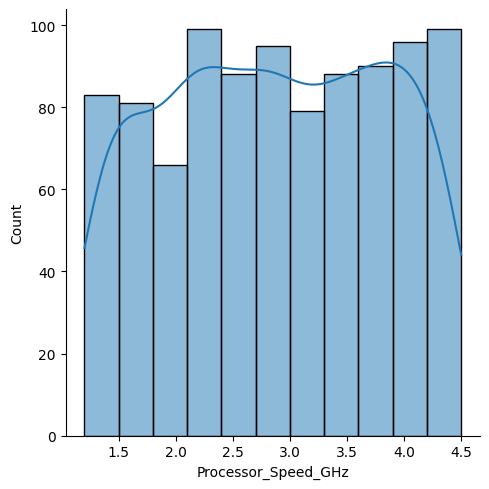

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.displot(data['Processor_Speed_GHz'],kde=True)
plt.show()
# the displot is uniform so we used mean to replace the null values 

In [13]:
#-0.5 to 0.5 → Approximately symmetric-mean
#-1 to -0.5 or 0.5 to 1 → Moderately skewed -median
#Less than -1 or Greater than 1 → Highly skewed -median 

In [14]:
data['Processor_Speed_GHz'].skew()
#the distribution of the feature Processor_Speed_GHz is symmetric and the skew value is -0.5 to 0.5 so we can use mean to fill the missing value 

np.float64(-0.034042927704070185)

In [20]:
mean_Processor_Speed=round(data['Processor_Speed_GHz'].mean(),1)
mean_Processor_Speed

np.float64(2.9)

In [21]:
data['Processor_Speed_GHz'].fillna(mean_Processor_Speed,inplace=True)

In [22]:
data.isnull().sum()

RAM_GB                     0
Processor_Speed_GHz        0
Storage_Type               0
Age_Months                 0
Battery_Health_Percent    51
Color                      0
Brand_Popularity_Score     0
Price_USD                  0
dtype: int64

In [23]:
data['Battery_Health_Percent'].value_counts()

Battery_Health_Percent
100.000000    39
97.369091      2
60.904328      2
84.789831      2
63.897471      2
              ..
96.213228      1
64.457104      1
96.623883      1
87.617018      1
92.641796      1
Name: count, Length: 913, dtype: int64

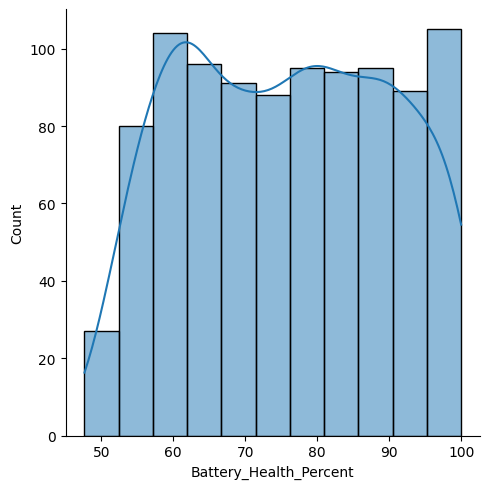

In [24]:
sns.displot(data['Battery_Health_Percent'],kde=True)
plt.show()

In [ ]:
data['Battery_Health_Percent'].skew()
# now we can use mean value to fill the null value because Approximately symmetric betweeen -0.5 to 0.5

np.float64(0.023484711026219553)

In [28]:
mean_Battery_Health_Percent=data['Battery_Health_Percent'].mean()
mean_Battery_Health_Percent

np.float64(75.86895190242909)

In [29]:
data['Battery_Health_Percent'].fillna(mean_Battery_Health_Percent,inplace=True)

C:\Users\VISHVA.S\AppData\Local\Temp\ipykernel_28228\1949409981.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Battery_Health_Percent'].fillna(mean_Battery_Health_Percent,inplace=True)


In [30]:
data.isnull().sum()

RAM_GB                    0
Processor_Speed_GHz       0
Storage_Type              0
Age_Months                0
Battery_Health_Percent    0
Color                     0
Brand_Popularity_Score    0
Price_USD                 0
dtype: int64

remove duplicate records

In [39]:
# because the row  is appear multiple the thinks the duplicate record is more important
#The model may learn repeated examples too strongly-Overfitting Risk
data_duplicate=data[data.duplicated(keep=False)]
print(data_duplicate)

     RAM_GB  Processor_Speed_GHz Storage_Type  Age_Months  \
14     8 GB                  2.4         NVMe          17   
23      8GB                  1.4         NVMe           4   
69      8GB                  4.4          SSD          49   
124    8 GB                  2.4         NVMe          17   
125    8 GB                  3.5          HDD          59   
143   32 GB                  3.2          SSD          39   
163    4 GB                  3.1          SSD          20   
180    8 GB                  2.9         NVMe          36   
228     8GB                  4.4          SSD          49   
245    16GB                  2.2          SSD          52   
250     8GB                  1.4         NVMe           4   
300    32GB                  2.2          SSD          51   
346    4 GB                  3.1          SSD          20   
349    8 GB                  2.1          SSD           0   
391    16GB                  2.2          SSD          52   
404    8 GB             

In [40]:
data=data.drop_duplicates()

In [42]:
data.duplicated().sum()

np.int64(0)

Check Outliers Using Boxplot

In [43]:
data

,RAM_GB,Processor_Speed_GHz,Storage_Type,Age_Months,Battery_Health_Percent,Color,Brand_Popularity_Score,Price_USD
0,16GB,2.1,HDD,30,77.768048,Space Gray,91,562.397622
1,8 GB,3.6,SSD,15,90.190981,Matte Black,2,951.058104
2,8GB,3.7,SSD,27,75.868952,Silver,19,791.169031
3,16 GB,1.2,NVMe,38,71.654528,Matte Black,15,652.522101
4,16GB,1.9,SSD,19,82.978123,Matte Black,18,833.020998
...,...,...,...,...,...,...,...,...
1010,8GB,4.0,HDD,42,64.457104,Rose Gold,97,739.908114
1011,16 GB,1.5,NVMe,5,96.623883,Rose Gold,33,979.477500
1012,16 GB,4.1,NVMe,14,87.617018,Silver,36,1387.943396
1013,16GB,2.5,SSD,33,75.868952,Rose Gold,18,839.771125


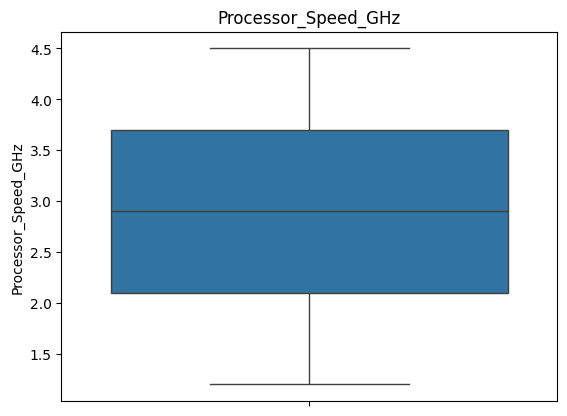

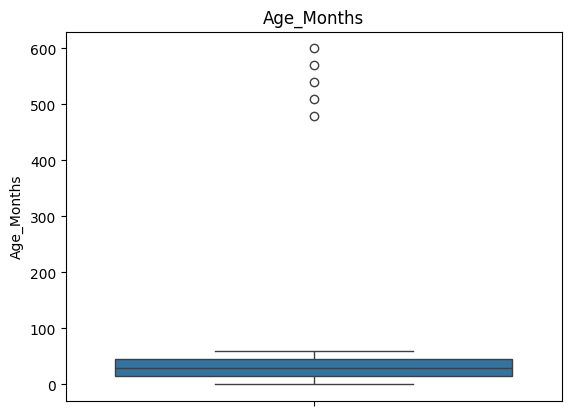

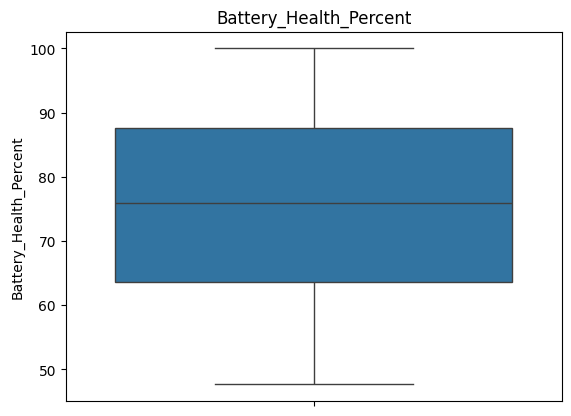

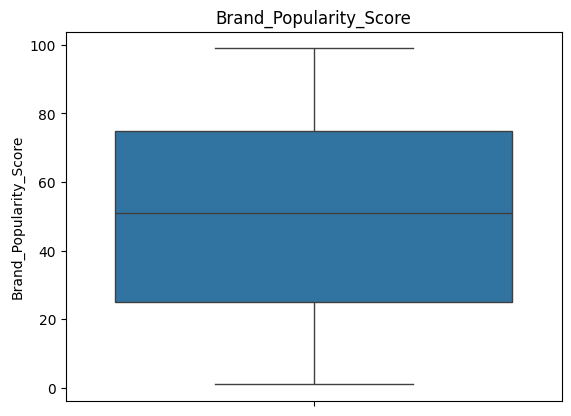

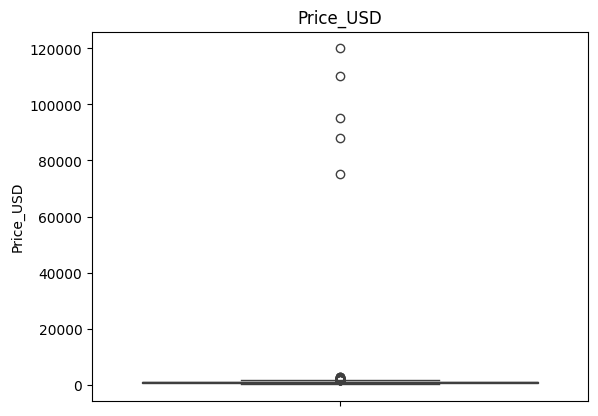

In [47]:
num_col=data.select_dtypes(include=['int64','float64']).columns
for col in num_col:
  sns.boxplot(data[col])
  plt.title(col)
  plt.show()